# ML-QEM Pipeline: Grover Algorithm on spinq 2 qubit nmr computer using spinq cloud



## Step 1: Environment Setup & Imports



In [1]:
!pip install -q qiskit qiskit-aer qiskit-ibm-runtime matplotlib scikit-learn scipy torch qiskit-experiments
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import random
import os

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator as IdealEstimator
from qiskit_aer.primitives import Estimator as NoisyEstimator
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2, Session
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_experiments.library import ProcessTomography
import warnings
warnings.filterwarnings("ignore")



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import random
import torch
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_experiments.library import ProcessTomography
from qiskit_experiments.framework import ExperimentData
from qiskit import transpile
import qiskit.qasm2 as qasm2
import tempfile
import os
from spinqit import get_compiler, Circuit
# Import cloud backend instead of local NMR
from spinqit import get_spinq_cloud, SpinQCloudConfig

# Initialize spinq cloud backend 
comp = get_compiler('qasm')

# Enter the cloud credentials 
# username = "Nethmini_Kar"
# keyfile = "C:/Users/nethm/.ssh/id_rsa"
username = "NethminiK"
keyfile = "D:/Academic UOP/Internship/NMR/id"

spinq_engine = get_spinq_cloud(username=username, keyfile=keyfile) 

import time
from spinqit.backend.spinq_cloud_backend import SpinQCloudBackend

def resilient_execute(self, ir, config):
    for i in range(10): # retry submission if it fails
        try:
            status, msg, task_code = self.submit_task(ir, config)
            break
        except Exception as e:
            if i == 9: raise e
            time.sleep(3)
            
    if status == 200 or status == 202:
        print(f'Task {task_code} has been submitted successfully. Polling resiliently...')
        while True:
            try:
                result = self.get_task_result(task_code)
                return result
            except Exception as e:
                err_str = str(e)
                if 'Read timed out' in err_str or '10060' in err_str or 'Timeout' in err_str or 'Connection aborted' in err_str or 'RemoteDisconnected' in err_str:
                    print(f'  [Network Timeout] Reconnecting to check Task {task_code}...')
                    time.sleep(3)
                else:
                    raise e
    else:
        raise Exception(f'Task submission failed: status code = {status}. Message = {msg}')

# Override the original execute method with our robust one
SpinQCloudBackend.execute = resilient_execute

config = SpinQCloudConfig()
config.configure_platform('gemini_vp') # Gemini 2 Qubit NMR
config.configure_shots(1024)
config.configure_task("dataset_gen", "Generating Dataset")

def compile_qiskit_to_spinq(qc, comp):
    # This bypasses the broken SpinQit 'qiskit' compiler by dumping to QASM first
    # SpinQ Cloud also does not support explicit measure gates (it measures automatically)
    qc_stripped = qc.copy()
    qc_stripped.data = [inst for inst in qc_stripped.data if inst.operation.name != 'measure']
    
    basis = ['id', 'rx', 'ry', 'rz', 'h', 'x', 'y', 'z', 'cx', 'cz']
    t_qc = transpile(qc_stripped, basis_gates=basis)
    fd, path = tempfile.mkstemp(suffix='.qasm')
    os.write(fd, qasm2.dumps(t_qc).encode('utf-8'))
    os.close(fd)
    exe = comp.compile(path, 0)
    os.remove(path)
    return exe

def get_choi_features_spinq(gate_circuit, physical_qubits, comp, engine, config):
    """
    Equivalent of `get_choi_features` using the SpinQit QASM Bridge.
    Extracts the physical noise footprint (Choi matrix) of a gate on SpinQ hardware.
    """
    # 1. Generate Qiskit Tomography Circuits
    qpt = ProcessTomography(gate_circuit, physical_qubits=physical_qubits)
    qiskit_circuits = qpt.circuits()
    
    # 2. Execute on SpinQit
    spinq_raw_data = []
    for qc in qiskit_circuits:
        exe = compile_qiskit_to_spinq(qc, comp)
        result = engine.execute(exe, config)
        spinq_raw_data.append(result.counts)
        
    # 3. Stitch counts back to Qiskit
    exp_data = ExperimentData(experiment=qpt)
    for i, circ in enumerate(qiskit_circuits):
        exp_data.add_data({"counts": spinq_raw_data[i], "metadata": circ.metadata})
        
    # 4. Run MLE Tomography and get Choi Matrix
    qpt.analysis.run(exp_data).block_for_results()
    flat_choi = np.array(exp_data.analysis_results("state").value).flatten()
    return np.concatenate((np.real(flat_choi), np.imag(flat_choi)))

# --- 1. GET HARDWARE FINGERPRINTS ---
qc_h, qc_x, qc_cz = QuantumCircuit(1), QuantumCircuit(1), QuantumCircuit(2)
qc_h.h(0)
qc_x.x(0)
qc_cz.cz(0, 1)

print("Extracting Hardware Fingerprints from SpinQit...")
hardware_fingerprint = np.concatenate([
    get_choi_features_spinq(qc_h, [0], comp, spinq_engine, config),
    get_choi_features_spinq(qc_x, [0], comp, spinq_engine, config),
    get_choi_features_spinq(qc_cz, [0, 1], comp, spinq_engine, config)
])
np.save("hardware_fingerprint.npy", hardware_fingerprint)
print("Hardware fingerprint saved to disk!")

--- RUNNING IN TEST MODE (LOCAL NOISY SIMULATOR) ---


In [ ]:
import random
import torch
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_experiments.library import ProcessTomography
from qiskit_experiments.framework import ExperimentData
from qiskit import transpile
import qiskit.qasm2 as qasm2
import tempfile
from spinqit import get_compiler, Circuit
# Import cloud backend instead of local NMR
from spinqit import get_spinq_cloud, SpinQCloudConfig
import csv
import os
import time
from spinqit.backend.spinq_cloud_backend import SpinQCloudBackend

# Initialize spinq cloud backend 
comp = get_compiler('qasm')

# Enter the cloud credentials 
username = "Nethmini_Kar"
keyfile = "C:/Users/nethm/.ssh/id_rsa"
# username = "NethminiK"
# keyfile = "D:/Academic UOP/Internship/NMR/id"

spinq_engine = get_spinq_cloud(username=username, keyfile=keyfile) 

csv_filename = "spinq_dataset.csv"
file_exists = os.path.isfile(csv_filename)

completed_circuits =0
if file_exists:
    with open(csv_filename,"r") as f:
        completed_circuits = max(0,sum(1 for line in f)-1)

TOTAL_TARGET = 500
NUM_CIRCUITS = TOTAL_TARGET -completed_circuits
print(f"Found {completed_circuits} circuits already saved.")
print(f"Need to generate {NUM_CIRCUITS} more to reach {TOTAL_TARGET}...")

if NUM_CIRCUITS <= 0:
    print("Dataset is already complete! Exiting.")
    exit()

def compile_qiskit_to_spinq(qc, comp):
    # This bypasses the broken SpinQit 'qiskit' compiler by dumping to QASM first
    # SpinQ Cloud also does not support explicit measure gates (it measures automatically)
    qc_stripped = qc.copy()
    qc_stripped.data = [inst for inst in qc_stripped.data if inst.operation.name != 'measure']
    
    basis = ['id', 'rx', 'ry', 'rz', 'h', 'x', 'y', 'z', 'cx', 'cz']
    t_qc = transpile(qc_stripped, basis_gates=basis)

        
    fd, path = tempfile.mkstemp(suffix='.qasm')
    os.write(fd, qasm2.dumps(t_qc).encode('utf-8'))
    os.close(fd)
    exe = comp.compile(path, 0)
    os.remove(path)
    return exe


def resilient_execute(self, ir, config):
    for i in range(10): # retry submission if it fails
        try:
            status, msg, task_code = self.submit_task(ir, config)
            break
        except Exception as e:
            if i == 9: raise e
            time.sleep(3)
            
    if status == 200 or status == 202:
        print(f'Task {task_code} has been submitted successfully. Polling resiliently...')
        while True:
            try:
                result = self.get_task_result(task_code)
                return result
            except Exception as e:
                err_str = str(e)
                if 'Read timed out' in err_str or '10060' in err_str or 'Timeout' in err_str or 'Connection aborted' in err_str or 'RemoteDisconnected' in err_str:
                    print(f'  [Network Timeout] Reconnecting to check Task {task_code}...')
                    time.sleep(3)
                else:
                    raise e
    else:
        raise Exception(f'Task submission failed: status code = {status}. Message = {msg}')

# Override the original execute method with our robust one
SpinQCloudBackend.execute = resilient_execute

config = SpinQCloudConfig()
config.configure_platform('gemini_vp') # Gemini 2 Qubit NMR
config.configure_shots(1024)
config.configure_task("dataset_gen", "Generating Dataset")

# load tomography circuits 
hardware_fingerprint = np.load("hardware_fingerprint.npy")

# Open a file to append data one row at a time 
f = open(csv_filename, "a", newline="")
writer = csv.writer(f)
if not file_exists:
    writer.writerow(["ideal_exp", "f1_depth", "f2_H_count", "f3_noisy_exp", 
"f4_CZ_count", "f5_X_count", "f6_1Q_count", "f7_2Q_count", "f8_width"])

print("Calculating ideal expectations using Qiskit StatevectorEstimator...")
# # --- 2. CIRCUIT GENERATION & NOISY EXPECTATION VALUES ---
observable = SparsePauliOp(["ZZ"]) # Example observable

def get_spinq_expectation(qiskit_circuit, observable, comp, engine, config):
    """
    Runs a Qiskit circuit on SpinQit and calculates the expectation value of the observable.
    """
    # Append measurements to all qubits to get counts
    qc_measured = qiskit_circuit.copy()
    qc_measured.measure_all()
    
    # Run on SpinQit
    exe = compile_qiskit_to_spinq(qc_measured, comp)
    result = engine.execute(exe, config)
    counts = result.counts
    
    # Calculate expectation value (Example for ZZ)
    total_shots = sum(counts.values())
    expectation = 0
    for bitstring, count in counts.items():
        # Clean up bitstring format if SpinQ outputs tuples or spaces
        bitstring = str(bitstring).replace(" ", "") 
        
        # Parity calculation for ZZ (assuming 2 qubits)
        parity = 1 if bitstring.count('1') % 2 == 0 else -1
        expectation += parity * (count / total_shots)
        
    return expectation

print("Generating Dataset...")
X_circuits_list, Y_targets_list = [], []

def make_grover_11():
    qc = QuantumCircuit(2, name="Grover_11")
    qc.h([0, 1]); qc.cz(0, 1); qc.h([0, 1]); qc.x([0, 1]); qc.cz(0, 1); qc.x([0, 1]); qc.h([0, 1])
    return qc

def make_grover_00():
    qc = QuantumCircuit(2, name="Grover_00")
    qc.x([0, 1]); qc.h([0, 1]); qc.cz(0, 1); qc.h([0, 1]); qc.x([0, 1]); qc.cz(0, 1); qc.x([0, 1]); qc.h([0, 1]); qc.x([0, 1])
    return qc

def make_double_grover():
    qc = QuantumCircuit(2, name="Double_Grover")
    for _ in range(2):
        qc.h([0, 1]); qc.cz(0, 1); qc.h([0, 1]); qc.x([0, 1]); qc.cz(0, 1); qc.x([0, 1]); qc.h([0, 1])
    return qc

def make_grover_with_rotations():
    qc = QuantumCircuit(2, name="Grover_rotated")
    qc.x(0); qc.h(1); qc.h([0, 1]); qc.cz(0, 1); qc.h([0, 1]); qc.x([0, 1]); qc.cz(0, 1); qc.x([0, 1]); qc.h([0, 1]); qc.h(0); qc.x(1)
    return qc

def generate_grover_basis_circuit(depth):
    qc = QuantumCircuit(2)
    available_gates = ["h0", "h1", "x0", "x1", "cz"]
    for _ in range(depth):
        gate = np.random.choice(available_gates)
        if gate == "h0": qc.h(0)
        elif gate == "h1": qc.h(1)
        elif gate == "x0": qc.x(0)
        elif gate == "x1": qc.x(1)
        elif gate == "cz": qc.cz(0, 1)
    return qc

def extract_circuit_features(qc, noisy_exp):
    ops = qc.count_ops()
    f1 = qc.depth()                     # 0: Total Depth
    f2 = ops.get("h", 0)                # 1: H-gate count
    f3 = noisy_exp                      # 2: Raw Noisy Measurement
    f4 = ops.get("cz", 0)               # 3: CZ-gate count
    f5 = ops.get("x", 0)                # 4: X-gate count
    f6 = f2 + f5                        # 5: Total 1Q gates
    f7 = qc.num_nonlocal_gates()        # 6: Total 2Q gates
    f8 = qc.width()                     # 7: Qubit width
    return [f1, f2, f3, f4, f5, f6, f7, f8]

from qiskit.primitives import StatevectorEstimator as IdealEstimator
ideal_estimator = IdealEstimator()
structured_funcs = [make_grover_11, make_grover_00, make_double_grover, make_grover_with_rotations]

circuit_list, pub_list_ideal = [], []

for _ in range(NUM_CIRCUITS):
    qc = generate_grover_basis_circuit(random.randint(3, 11)) if random.random() < 0.8 else random.choice(structured_funcs)()
    circuit_list.append(qc)
    pub_list_ideal.append((qc, observable))

print("Calculating ideal expectations using Qiskit StatevectorEstimator...")
result_ideal = ideal_estimator.run(pub_list_ideal).result()

for i in range(NUM_CIRCUITS):
    qc = circuit_list[i]
    ideal_exp = float(np.squeeze(result_ideal[i].data.evs))
    
    # Get noisy expectation from SpinQ hardware
    try:
        noisy_exp = get_spinq_expectation(qc, observable, comp, spinq_engine, config)
    except Exception as e:
        if "empty circuit" in str(e).lower():
            print(f"Skipping circuit {i} because it optimized to an empty circuit!")
            continue
        raise e
        
    features = extract_circuit_features(qc,noisy_exp)
    # save this single row to csv immediately
    row =[ideal_exp] + features
    writer.writerow(row)
    f.flush() # forces it to save to the hard drive immediately 
    X_circuits_list.append(extract_circuit_features(qc, noisy_exp))
    Y_targets_list.append([ideal_exp])

X_circuits_t = torch.tensor(X_circuits_list, dtype=torch.float32)
Y_targets_t = torch.tensor(Y_targets_list, dtype=torch.float32)
print("--- SPINQ DATASET GENERATED SUCCESSFULLY ---")


## Step 2: Circuit Generators & Feature Extraction
Defines the structural logic of the Grover Algorithm and extracts the 8 critical features (depth, gate counts, raw noisy expectation) used in Tower A.


In [19]:
def make_grover_11():
    qc = QuantumCircuit(2, name="Grover_11")
    qc.h([0, 1]); qc.cz(0, 1); qc.h([0, 1]); qc.x([0, 1]); qc.cz(0, 1); qc.x([0, 1]); qc.h([0, 1])
    return qc

def make_grover_00():
    qc = QuantumCircuit(2, name="Grover_00")
    qc.x([0, 1]); qc.h([0, 1]); qc.cz(0, 1); qc.h([0, 1]); qc.x([0, 1]); qc.cz(0, 1); qc.x([0, 1]); qc.h([0, 1]); qc.x([0, 1])
    return qc

def make_double_grover():
    qc = QuantumCircuit(2, name="Double_Grover")
    for _ in range(2):
        qc.h([0, 1]); qc.cz(0, 1); qc.h([0, 1]); qc.x([0, 1]); qc.cz(0, 1); qc.x([0, 1]); qc.h([0, 1])
    return qc

def make_grover_with_rotations():
    qc = QuantumCircuit(2, name="Grover_rotated")
    qc.x(0); qc.h(1); qc.h([0, 1]); qc.cz(0, 1); qc.h([0, 1]); qc.x([0, 1]); qc.cz(0, 1); qc.x([0, 1]); qc.h([0, 1]); qc.h(0); qc.x(1)
    return qc

def generate_grover_basis_circuit(depth):
    qc = QuantumCircuit(2)
    available_gates = ["h0", "h1", "x0", "x1", "cz"]
    for _ in range(depth):
        gate = np.random.choice(available_gates)
        if gate == "h0": qc.h(0)
        elif gate == "h1": qc.h(1)
        elif gate == "x0": qc.x(0)
        elif gate == "x1": qc.x(1)
        elif gate == "cz": qc.cz(0, 1)
    return qc

def extract_circuit_features(qc, noisy_exp):
    ops = qc.count_ops()
    f1 = qc.depth()                     # 0: Total Depth
    f2 = ops.get("h", 0)                # 1: H-gate count
    f3 = noisy_exp                      # 2: Raw Noisy Measurement
    f4 = ops.get("cz", 0)               # 3: CZ-gate count
    f5 = ops.get("x", 0)                # 4: X-gate count
    f6 = f2 + f5                        # 5: Total 1Q gates
    f7 = qc.num_nonlocal_gates()        # 6: Total 2Q gates
    f8 = qc.width()                     # 7: Qubit width
    return [f1, f2, f3, f4, f5, f6, f7, f8]


## Step 3: Hardware Tomography & Data Generation



In [7]:
import pandas as pd
import torch
import numpy as np

DATA_DIR = "data_nmr/"

# 1. Load the hardware fingerprint (exactly the same as before)
hardware_fingerprint = np.load(f"{DATA_DIR}hardware_fingerprint.npy")

# 2. Load the CSV file
df = pd.read_csv(f"{DATA_DIR}spinq_dataset.csv")

# 3. Split the csv into y targets (col 0) and x features (col1 to 8)
y_data = df.iloc[:, 0].values
x_data = df.iloc[:,1:].values

# 4. convert back to pytorch tensors so NN can seamlessly consume
Y_targets_t = torch.tensor(y_data,dtype=torch.float32).unsqueeze(1) # shape (500,1)
X_circuits_t = torch.tensor(x_data,dtype=torch.float32) # shape (500,8)

print(f"Loaded {len(X_circuits_t)} physical NMR circuits!")
print("Data loaded successfully! Ready for the ML Pipeline.")


Loaded 500 physical NMR circuits!
Data loaded successfully! Ready for the ML Pipeline.


## Step 4: ML Model Training & CPTP Augmentation
Applies physically valid Completely Positive Trace-Preserving (CPTP) depolarizing noise to the hardware fingerprint during training. This forces Tower B to learn a generalized hardware embedding instead of collapsing to a constant bias. The model uses strong regularization to avoid overfitting to IBM baseline stochastic noise.


Identified 236 unique circuit structures in 500 circuits.
Train: 420 circuits | Test: 80 circuits
Train groups: 188 | Test groups: 48
Group overlap: 0 (should be 0)

Deep test circuits (depth > 8): 8
--- READY FOR TRAINING (LEAK-FREE) ---

--- TRAINING MODEL ---
Epoch    | Train Loss      | Val Loss (Huber)   | Avg Val Pred   
-----------------------------------------------------------------
0        | 445.895375      | 0.008873           | 0.023232       
50       | 0.431012        | 0.007487           | -0.004234      
100      | 0.257346        | 0.006964           | 0.013345       
150      | 0.188223        | 0.006187           | -0.000768      
200      | 0.138302        | 0.006186           | 0.012556       
250      | 0.114762        | 0.006264           | -0.023351      
300      | 0.096665        | 0.006973           | 0.004061       
350      | 0.099355        | 0.006481           | -0.001647      
400      | 0.077076        | 0.006118           | -0.010118      
450      | 

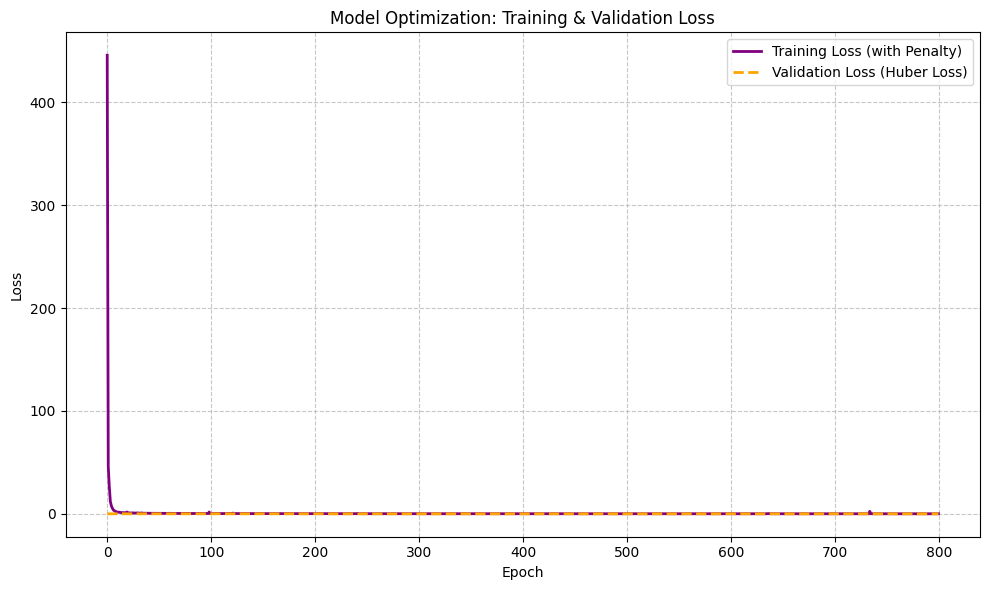

In [16]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupShuffleSplit
import matplotlib.pyplot as plt

NUM_CIRCUITS =len(X_circuits_t)
# ============================================================
# CPTP Perturbation (unchanged)
# ============================================================
def cptp_perturb_choi(hw_vec, p, gate_dims=[(4, 32), (4, 32), (16, 512)]):
    """Apply depolarizing mixing to each gate's Choi sub-vector."""
    perturbed = hw_vec.copy()
    offset = 0
    for d_sq, n_feat in gate_dims:
        d = int(np.sqrt(d_sq))
        half = n_feat // 2
        re = perturbed[offset : offset + half]
        im = perturbed[offset + half : offset + n_feat]
        choi_id_re = np.eye(d_sq).flatten() / d
        choi_id_im = np.zeros_like(choi_id_re)
        re[:] = (1 - p) * re + p * choi_id_re
        im[:] = (1 - p) * im + p * choi_id_im
        offset += n_feat
    return perturbed
# ============================================================
# 1. ASSIGN GROUP IDs TO PREVENT DUPLICATE LEAKAGE
# ============================================================
# Circuits with identical structural features get the same group ID.
# This ensures ALL copies of make_grover_11() stay in the same partition.
feature_to_group = {}
group_ids = []
next_group = 0
for i in range(NUM_CIRCUITS):
    # Use all features EXCEPT column 2 (noisy measurement varies per shot)
    key = tuple(X_circuits_t[i, [0,1,3,4,5,6,7]].tolist())
    if key not in feature_to_group:
        feature_to_group[key] = next_group
        next_group += 1
    group_ids.append(feature_to_group[key])
group_ids = np.array(group_ids)
print(f"Identified {next_group} unique circuit structures in {NUM_CIRCUITS} circuits.")
# ============================================================
# 2. GROUP-AWARE SPLIT: No structure leaks across the boundary
# ============================================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_circuits_t.numpy(), groups=group_ids))
print(f"Train: {len(train_idx)} circuits | Test: {len(test_idx)} circuits")
print(f"Train groups: {len(set(group_ids[train_idx]))} | Test groups: {len(set(group_ids[test_idx]))}")
overlap = len(set(group_ids[train_idx]) & set(group_ids[test_idx]))
print(f"Group overlap: {overlap} (should be 0)")
assert overlap == 0, "DATA LEAKAGE DETECTED! Groups overlap between train and test!"
# ============================================================
# 3. SPLIT FIRST, THEN NORMALIZE FROM TRAINING STATS ONLY
# ============================================================
X_circ_raw_train = X_circuits_t[train_idx].clone()
X_circ_raw_test  = X_circuits_t[test_idx].clone()
# Store un-normalized depths BEFORE normalization (for plotting in Step 5)
test_depths_raw = X_circuits_t[test_idx, 0].numpy().copy()
# Compute normalization stats from TRAINING data ONLY
norm_stats = {}
for col in [0, 1, 3, 4, 5, 6, 7]:
    mean = X_circ_raw_train[:, col].mean()
    std  = X_circ_raw_train[:, col].std()
    norm_stats[col] = (mean.item(), std.item())
    X_circ_raw_train[:, col] = (X_circ_raw_train[:, col] - mean) / (std + 1e-8)
    X_circ_raw_test[:, col]  = (X_circ_raw_test[:, col]  - mean) / (std + 1e-8)
Xc_train_t = X_circ_raw_train
Xc_test_t  = X_circ_raw_test
Y_train_t  = Y_targets_t[train_idx]
Y_test_t   = Y_targets_t[test_idx]
# Hardware fingerprint
X_hw_base = torch.tensor(hardware_fingerprint, dtype=torch.float32).unsqueeze(0).repeat(NUM_CIRCUITS, 1)
Xh_test_t = X_hw_base[test_idx]
# CPTP Augmentation — strictly on training data
P_MAX = 0.05
Xh_train_t = torch.tensor(
    np.array([cptp_perturb_choi(hardware_fingerprint, np.random.uniform(0, P_MAX)) for _ in range(len(train_idx))]),
    dtype=torch.float32
)
train_loader = DataLoader(TensorDataset(Xc_train_t, Xh_train_t, Y_train_t), batch_size=32, shuffle=True)
deep_count = int(sum(test_depths_raw > 8))
print(f"\nDeep test circuits (depth > 8): {deep_count}")
print("--- READY FOR TRAINING (LEAK-FREE) ---")
# ============================================================
# 4. MODEL DEFINITION (HEAVY NOISE EDITION)
# ============================================================
class TwoTowerQEM_Fixed(nn.Module):
    # Increased hidden dimensions to capture complex physical noise
    def __init__(self, circ_dim=8, hw_dim=576, embed_dim=16, hidden_dim=64):
        super().__init__()
        # Reduced dropout so the model can actually learn
        self.circ_tower = nn.Sequential(nn.Linear(circ_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.SiLU(), nn.Dropout(0.2))
        self.hw_embedding = nn.Sequential(nn.Linear(hw_dim, embed_dim), nn.Tanh())
        
        self.fusion = nn.Sequential(nn.Linear(hidden_dim + embed_dim, hidden_dim // 2), nn.BatchNorm1d(hidden_dim // 2), nn.SiLU(), nn.Linear(hidden_dim // 2, 1))
        
        nn.init.normal_(self.fusion[-1].weight, mean=0.0, std=0.01)
        nn.init.constant_(self.fusion[-1].bias, 0.0)

    def forward(self, x_circ, x_hw):
        fused_state = torch.cat([self.circ_tower(x_circ), self.hw_embedding(x_hw)], dim=1)
        
        # REMOVED THE 0.2 BOUND! The model can now apply massive corrections
        bounded_correction = torch.tanh(self.fusion(fused_state)) * 1.0 
        
        residual_state = x_circ[:,2].unsqueeze(1) + bounded_correction
        return torch.clamp(residual_state, min=-1.0, max=1.0)

# ============================================================
# 5. TRAINING LOOP WITH TABULAR LOGGING
# ============================================================
model_fixed = TwoTowerQEM_Fixed()
criterion = nn.HuberLoss(delta=0.1) # Increased delta for larger errors
# Reduced weight decay
optimizer = optim.AdamW(model_fixed.parameters(), lr=0.003, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", patience=20, factor=0.5)

train_losses = []
val_losses = []

print("\n--- TRAINING MODEL ---")
print(f"{'Epoch':<8} | {'Train Loss':<15} | {'Val Loss (Huber)':<18} | {'Avg Val Pred':<15}")
print("-" * 65)

# Increased epochs to 800 to give it time to converge
for epoch in range(800):
    epoch_loss = 0
    model_fixed.train()
    for b_xc, b_xh, b_y in train_loader:
        optimizer.zero_grad()
        
        total_loss = criterion(model_fixed(b_xc, b_xh), b_y) + 0.005 * (1.0 / (model_fixed.hw_embedding(b_xh).var(dim=0).mean() + 1e-6))
        total_loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model_fixed.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += total_loss.item()
        
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    scheduler.step(epoch_loss)
    
    model_fixed.eval()
    with torch.no_grad():
        val_pred = model_fixed(Xc_test_t, Xh_test_t)
        val_loss = criterion(val_pred, Y_test_t).item()
        val_losses.append(val_loss)
        
    if epoch % 50 == 0 or epoch == 799:
        avg_pred = val_pred.mean().item()
        print(f"{epoch:<8} | {avg_train_loss:<15.6f} | {val_loss:<18.6f} | {avg_pred:<15.6f}")

print("-" * 65)
print("Training Complete!")

# ============================================================
# 6. LOSS CURVE PLOT
# ============================================================
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Training Loss (with Penalty)", color="purple", linewidth=2)
plt.plot(val_losses, label="Validation Loss (Huber Loss)", color="orange", linewidth=2, linestyle="--")
plt.title("Model Optimization: Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=300)
print("\n>>> Saved loss_curve.png for your paper!")

## Step 5: Retrospective Analysis & Paper Visualization
Mathematically proves that the ML model selectively ignores shallow random circuits (where the error is pure shot-noise) and heavily mitigates deep structured circuits (where coherent decay dominates). Generates a visualization for the publication.


RETROSPECTIVE ANALYSIS: UNSEEN TEST DATA (80 CIRCUITS)

--- CIRCUITS (Depth > 6) (26 samples) ---
  Raw MAE:       0.169666
  Mitigated MAE: 0.149703
  Error Reduction: 11.8%
  Wilcoxon p-value: 0.032655
  >>> SIGNIFICANT

--- CIRCUITS (Depth > 8) (8 samples) ---
  Only 8 samples - insufficient for statistical test

--- CIRCUITS (Depth > 10) (0 samples) ---
  Only 0 samples - insufficient for statistical test

--- ALL TEST CIRCUITS (80 samples) ---
  Raw MAE:       0.110323
  Mitigated MAE: 0.078538
  Error Reduction: 28.8%
  Wilcoxon p-value: 0.000510
  >>> SIGNIFICANT

>>> Saved error_vs_depth.png for your paper!


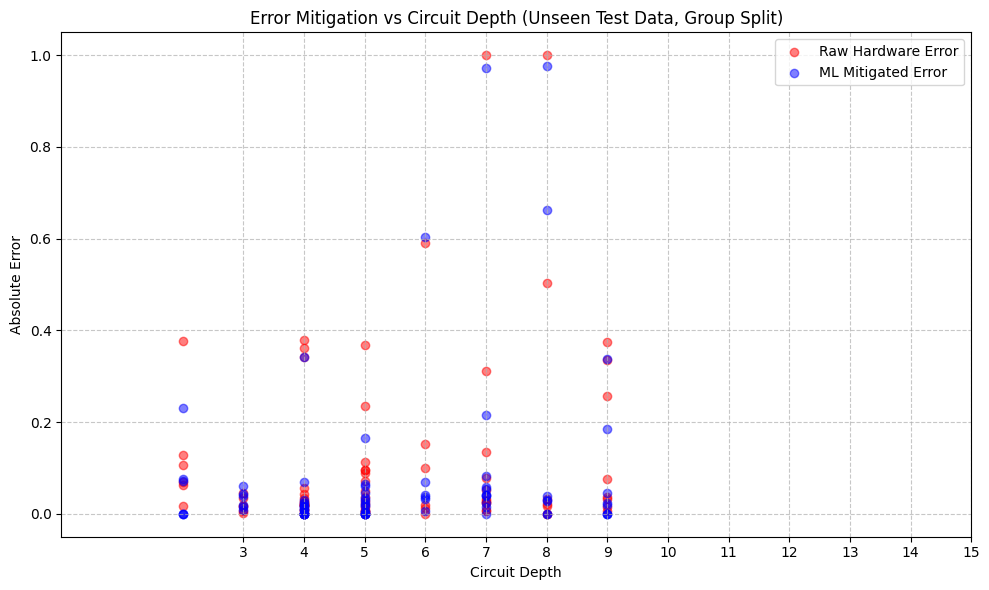

In [17]:
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
model_fixed.eval()
with torch.no_grad():
    test_preds = model_fixed(Xc_test_t, Xh_test_t).numpy().flatten()
    test_true  = Y_test_t.numpy().flatten()
    test_noisy = Xc_test_t[:, 2].numpy()  # Column 2 was never normalized
    raw_errors = np.abs(test_true - test_noisy)
    mit_errors = np.abs(test_true - test_preds)
print("=" * 60)
print(f"RETROSPECTIVE ANALYSIS: UNSEEN TEST DATA ({len(test_preds)} CIRCUITS)")
print("=" * 60)
# Report at multiple depth thresholds for robustness
for threshold in [6, 8, 10]:
    deep_mask = test_depths_raw > threshold
    num_deep = int(sum(deep_mask))
    print(f"\n--- CIRCUITS (Depth > {threshold}) ({num_deep} samples) ---")
    if num_deep >= 10:
        deep_raw_mae = np.mean(raw_errors[deep_mask])
        deep_mit_mae = np.mean(mit_errors[deep_mask])
        reduction = ((deep_raw_mae - deep_mit_mae) / deep_raw_mae) * 100
        stat, p_val = wilcoxon(raw_errors[deep_mask], mit_errors[deep_mask], alternative="greater")
        print(f"  Raw MAE:       {deep_raw_mae:.6f}")
        print(f"  Mitigated MAE: {deep_mit_mae:.6f}")
        print(f"  Error Reduction: {reduction:.1f}%")
        print(f"  Wilcoxon p-value: {p_val:.6f}")
        print("  >>> SIGNIFICANT" if p_val < 0.05 else "  >>> NOT SIGNIFICANT")
    else:
        print(f"  Only {num_deep} samples - insufficient for statistical test")
# Full dataset summary
print(f"\n--- ALL TEST CIRCUITS ({len(test_preds)} samples) ---")
full_raw_mae = np.mean(raw_errors)
full_mit_mae = np.mean(mit_errors)
full_reduction = ((full_raw_mae - full_mit_mae) / full_raw_mae) * 100
stat, p_val = wilcoxon(raw_errors, mit_errors, alternative="greater")
print(f"  Raw MAE:       {full_raw_mae:.6f}")
print(f"  Mitigated MAE: {full_mit_mae:.6f}")
print(f"  Error Reduction: {full_reduction:.1f}%")
print(f"  Wilcoxon p-value: {p_val:.6f}")
print("  >>> SIGNIFICANT" if p_val < 0.05 else "  >>> NOT SIGNIFICANT")
# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(test_depths_raw, raw_errors, alpha=0.5, label="Raw Hardware Error", color="red")
plt.scatter(test_depths_raw, mit_errors, alpha=0.5, label="ML Mitigated Error", color="blue")
plt.title("Error Mitigation vs Circuit Depth (Unseen Test Data, Group Split)")
plt.xlabel("Circuit Depth")
plt.ylabel("Absolute Error")
plt.xticks(range(3, 16))
plt.xlim(0, 15)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("error_vs_depth.png", dpi=300)
print("\n>>> Saved error_vs_depth.png for your paper!")

## Step 6: Target Inference on QPU (Optional)
Runs a batch evaluation of the target Grover circuit strictly on the IBM hardware (or simulator) to calculate live variance and error mitigation. This consumes QPU time if `TEST_MODE = False`.


In [21]:
# Change to True if you want to test the model with live inference data
RUN_LIVE_INFERENCE = True

if RUN_LIVE_INFERENCE:
    # --- STANDALONE SPINQ QPU SETUP ---
    from spinqit import get_compiler, get_spinq_cloud, SpinQCloudConfig
    from spinqit.backend.spinq_cloud_backend import SpinQCloudBackend
    import time
    import tempfile
    import os
    import qiskit.qasm2 as qasm2
    from qiskit import transpile

    # We will do a small number of runs to save your 200 tasks/day physical hardware quota!
    NUM_EVAL_RUNS = 30
    print(f"--- RUNNING LIVE INFERENCE ON SPINQ NMR ({NUM_EVAL_RUNS} EXECUTIONS) ---")
    
    # 1. SpinQ Authentication
    username = "Nethmini_Kar"
    keyfile = "C:/Users/nethm/.ssh/id_rsa"
    spinq_engine = get_spinq_cloud(username=username, keyfile=keyfile) 
    comp = get_compiler('qasm')
    
    config = SpinQCloudConfig()
    config.configure_platform('gemini_vp') # Gemini 2 Qubit NMR
    config.configure_shots(1024)
    config.configure_task("live_infer", "Live Inference ML")

    # 2. Resilient Execution (to handle SpinQ network timeouts)
    def resilient_execute(self, ir, config):
        for i in range(10): 
            try:
                status, msg, task_code = self.submit_task(ir, config)
                break
            except Exception as e:
                if i == 9: raise e
                time.sleep(3)
        if status == 200 or status == 202:
            print(f'  [SpinQ] Task {task_code} submitted. Polling resiliently...')
            while True:
                try:
                    result = self.get_task_result(task_code)
                    return result
                except Exception as e:
                    err_str = str(e)
                    if 'Read timed out' in err_str or '10060' in err_str or 'Timeout' in err_str or 'Connection aborted' in err_str or 'RemoteDisconnected' in err_str:
                        print(f'    [Network Timeout] Reconnecting to check Task {task_code}...')
                        time.sleep(3)
                    else:
                        raise e
        else:
            raise Exception(f'Task submission failed: {msg}')

    SpinQCloudBackend.execute = resilient_execute

    # 3. Compiler & Expectation Helper
    def compile_qiskit_to_spinq(qc, comp):
        qc_stripped = qc.copy()
        qc_stripped.data = [inst for inst in qc_stripped.data if inst.operation.name != 'measure']
        basis = ['id', 'rx', 'ry', 'rz', 'h', 'x', 'y', 'z', 'cx', 'cz']
        t_qc = transpile(qc_stripped, basis_gates=basis)
        fd, path = tempfile.mkstemp(suffix='.qasm')
        os.write(fd, qasm2.dumps(t_qc).encode('utf-8'))
        os.close(fd)
        exe = comp.compile(path, 0)
        os.remove(path)
        return exe

    def get_spinq_expectation(qiskit_circuit, observable, comp, engine, config):
        qc_measured = qiskit_circuit.copy()
        qc_measured.measure_all()
        exe = compile_qiskit_to_spinq(qc_measured, comp)
        result = engine.execute(exe, config)
        counts = result.counts
        total_shots = sum(counts.values())
        expectation = 0
        for bitstring, count in counts.items():
            bitstring = str(bitstring).replace(" ", "") 
            parity = 1 if bitstring.count('1') % 2 == 0 else -1
            expectation += parity * (count / total_shots)
        return expectation

    # 4. Target Circuit & Ideal Value
    from qiskit.primitives import StatevectorEstimator as IdealEstimator
    from qiskit.quantum_info import SparsePauliOp
    
    ideal_estimator = IdealEstimator()
    observable = SparsePauliOp("ZZ")
    target_circuit = make_grover_11()
    ideal_val = float(np.squeeze(ideal_estimator.run([(target_circuit, observable)]).result()[0].data.evs))

    # 5. Live Execution Loop
    noisy_vals = []
    for run_idx in range(NUM_EVAL_RUNS):
        print(f"Executing Live Run {run_idx+1}/{NUM_EVAL_RUNS}...")
        try:
            val = get_spinq_expectation(target_circuit, observable, comp, spinq_engine, config)
            noisy_vals.append(val)
        except Exception as e:
            if "empty circuit" in str(e).lower():
                print("Skipping - empty circuit optimized.")
            else:
                raise e

    # 6. ML Error Mitigation (using your newly trained TwoTowerQEM_Fixed model)
    mitigated_vals, raw_errors, mitigated_errors = [], [], []
    model_fixed.eval()
    with torch.no_grad():
        for noisy_val in noisy_vals:
            circ_feats = extract_circuit_features(target_circuit, noisy_val)
            xc_inf = torch.tensor([circ_feats], dtype=torch.float32)
            for col in [0, 1, 3, 4, 5, 6, 7]:
                mean, std = X_circuits_t[:, col].mean(), X_circuits_t[:, col].std()
                xc_inf[0, col] = (xc_inf[0, col] - mean) / (std + 1e-8)
            
            xh_inf = torch.tensor(hardware_fingerprint, dtype=torch.float32).unsqueeze(0)
            mit_val = float(model_fixed(xc_inf, xh_inf)[0][0])
            
            mitigated_vals.append(mit_val)
            raw_errors.append(abs(ideal_val - noisy_val))
            mitigated_errors.append(abs(ideal_val - mit_val))
    
    # 7. Summary
    if len(raw_errors) > 0:
        print("\n" + "="*60)
        print(f"  RAW ERROR:          {np.mean(raw_errors):.4f} ± {np.std(raw_errors):.4f}")
        print(f"  MITIGATED ERROR:    {np.mean(mitigated_errors):.4f} ± {np.std(mitigated_errors):.4f}")
        if sum(raw_errors) > 0 and len(raw_errors) >= 3: 
            try:
                from scipy.stats import wilcoxon
                print(f"  WILCOXON P-VALUE:   {wilcoxon(raw_errors, mitigated_errors, alternative='greater')[1]:.6f}")
            except Exception as e:
                print("  (Not enough variance/samples for Wilcoxon test)")
        print("="*60)
else:
    print("Live inference skipped.")


--- RUNNING LIVE INFERENCE ON SPINQ NMR (30 EXECUTIONS) ---
Executing Live Run 1/30...
  [SpinQ] Task G-260723-0221 submitted. Polling resiliently...
Executing Live Run 2/30...
  [SpinQ] Task G-260723-0222 submitted. Polling resiliently...
Executing Live Run 3/30...
  [SpinQ] Task G-260723-0223 submitted. Polling resiliently...
Executing Live Run 4/30...
  [SpinQ] Task G-260723-0224 submitted. Polling resiliently...
Executing Live Run 5/30...
  [SpinQ] Task G-260723-0225 submitted. Polling resiliently...
    [Network Timeout] Reconnecting to check Task G-260723-0225...
Executing Live Run 6/30...
  [SpinQ] Task G-260723-0226 submitted. Polling resiliently...
Executing Live Run 7/30...
  [SpinQ] Task G-260723-0227 submitted. Polling resiliently...
Executing Live Run 8/30...
  [SpinQ] Task G-260723-0228 submitted. Polling resiliently...
Executing Live Run 9/30...
  [SpinQ] Task G-260723-0229 submitted. Polling resiliently...
Executing Live Run 10/30...
  [SpinQ] Task G-260723-0230 submitt


>>> Saved live_inference_vals.png for your paper!


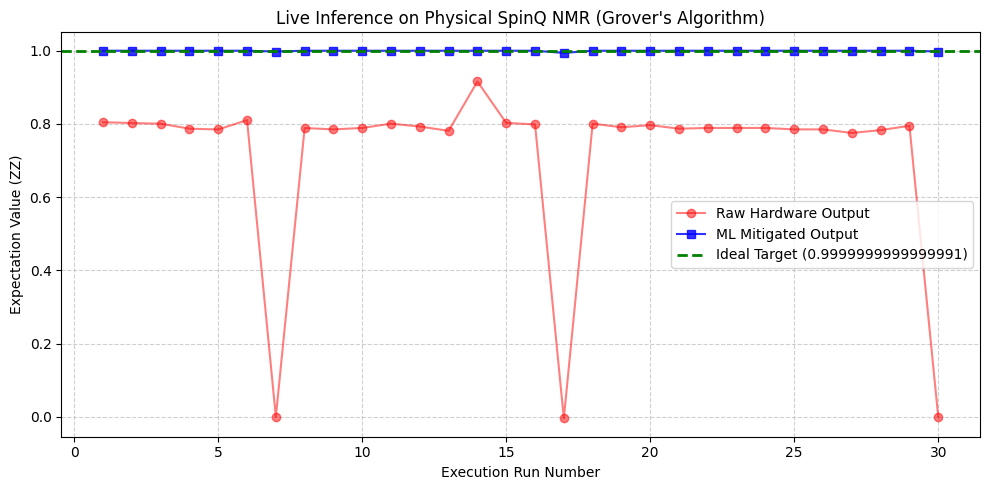

In [22]:
    # 8. Visualization of Live Inference
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 5))
    runs = range(1, len(noisy_vals) + 1)
    
    # Plot the raw values vs mitigated values
    plt.plot(runs, noisy_vals, marker='o', linestyle='-', color='red', alpha=0.5, label='Raw Hardware Output')
    plt.plot(runs, mitigated_vals, marker='s', linestyle='-', color='blue', alpha=0.8, label='ML Mitigated Output')
    
    # Draw the ideal target line
    plt.axhline(y=ideal_val, color='green', linestyle='--', linewidth=2, label=f'Ideal Target ({ideal_val})')
    
    plt.title("Live Inference on Physical SpinQ NMR (Grover's Algorithm)")
    plt.xlabel("Execution Run Number")
    plt.ylabel("Expectation Value (ZZ)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig("live_inference_vals.png", dpi=300)
    print("\n>>> Saved live_inference_vals.png for your paper!")


In [23]:
import pandas as pd
import torch
import json

DATA_DIR = "data_nmr/"

# 1. Save the Live Inference Results to CSV
inference_df = pd.DataFrame({
    'run_number': range(1, len(noisy_vals) + 1),
    'ideal_target': [ideal_val] * len(noisy_vals),
    'raw_hardware_val': noisy_vals,
    'mitigated_ml_val': mitigated_vals,
    'raw_absolute_error': raw_errors,
    'mitigated_absolute_error': mitigated_errors
})
inference_df.to_csv(f"{DATA_DIR}live_inference_results.csv", index=False)
print(f"Saved inference data to {DATA_DIR}live_inference_results.csv")

# 2. Save the Model Weights (State Dict - Best Practice)
torch.save(model_fixed.state_dict(), f"{DATA_DIR}twotower_qem_weights.pth")
print(f"Saved model weights to {DATA_DIR}twotower_qem_weights.pth")

# 3. Save the Full Model (Architecture + Weights - Easiest to load later)
torch.save(model_fixed, f"{DATA_DIR}twotower_qem_full_model.pth")
print(f"Saved full model to {DATA_DIR}twotower_qem_full_model.pth")

# 4. Save normalization statistics (Stored in the 'norm_stats' dict during Step 4)
with open(f"{DATA_DIR}normalization_stats.json", "w") as f:
    json.dump(norm_stats, f, indent=4)
print(f"Saved normalization stats to {DATA_DIR}normalization_stats.json")

print("\n>>> All experiment assets successfully saved! Your research is now fully reproducible.")


Saved inference data to data_nmr/live_inference_results.csv
Saved model weights to data_nmr/twotower_qem_weights.pth
Saved full model to data_nmr/twotower_qem_full_model.pth
Saved normalization stats to data_nmr/normalization_stats.json

>>> All experiment assets successfully saved! Your research is now fully reproducible.
